<a href="https://colab.research.google.com/github/aathipatcheri54-bot/aathikesavan/blob/main/EXP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Created synthetic image at: synthetic_elephant.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Top Predictions:
1: envelope (60.49%)
2: book_jacket (2.06%)
3: switch (1.87%)


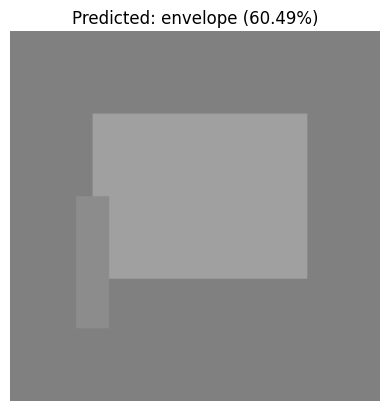

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image

# Since external downloads are restricted, we create a synthetic image for demonstration
img_path = 'synthetic_elephant.png'

# Create a gray rectangle representing a simple shape for the model to process
# (224, 224, 3) is the required input size for MobileNetV2
synthetic_img = np.full((224, 224, 3), 128, dtype=np.uint8)
synthetic_img[50:150, 50:180, :] = 160  # Add a 'body'
synthetic_img[100:180, 40:60, :] = 140  # Add a 'trunk'

plt.imsave(img_path, synthetic_img)
print(f"Created synthetic image at: {img_path}")

model = MobileNetV2(weights='imagenet')

try:
    if os.path.exists(img_path):
        # Load and preprocess the image
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)

        # Perform prediction
        preds = model.predict(img_array)
        decoded_preds = decode_predictions(preds, top=3)[0]

        print("\nTop Predictions:")
        for i, (id, label, score) in enumerate(decoded_preds):
            print(f"{i+1}: {label} ({score*100:.2f}%)")

        # Display result
        plt.imshow(img)
        top_label = decoded_preds[0][1]
        top_score = decoded_preds[0][2]
        plt.title(f"Predicted: {top_label} ({top_score*100:.2f}%)")
        plt.axis('off')
        plt.show()
    else:
        print("Image file not found.")
except Exception as e:
    print(f"Error processing image: {e}")